# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
print("Primeras filas de plans:")
display(plans.head(5))# mostrar las primeras 5 filas de plans

Primeras filas de plans:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
print("Primeras filas de users:")
display(users.head(5))# mostrar las primeras 5 filas de users

Primeras filas de users:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
print("Primeras filas de usage:")
display(usage.head(5))# mostrar las primeras 5 filas de usage

Primeras filas de usage:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
print("\nEstructura de plans:")
plans.info()# inspección de plans con .info()


Estructura de plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
print("\nEstructura de users:")
users.info()# inspección de users con .info()


Estructura de users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
print("\nEstructura de usage:")
usage.info()# inspección de usage con .info()


Estructura de usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Valores nulos en users:")
print(users.isnull().sum())# Cantidad de valores nulos)
print("\nProporción de valores nulos en users (%):")
print((users.isnull().mean() * 100).round(2))# Proporción de valores nulos)

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users (%):
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [11]:
print("\nValores nulos en usage:")
print(usage.isnull().sum())
print("\nProporción de valores nulos en usage (%):")
print((usage.isnull().mean() * 100).round(2))# cantidad de nulos para usage


Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage (%):
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print("Resumen estadístico de las variables numéricas en users:")
display(users.describe())# explorar columnas numéricas de users

Resumen estadístico de las variables numéricas en users:


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [13]:
print("Resumen estadístico de las variables numéricas en usage:")
display(usage.describe())# explorar columnas numéricas de usage

Resumen estadístico de las variables numéricas en usage:


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print("Valores únicos de las columnas categóricas en users:")

for columna in columnas_user:
    print(f"\n{columna}:")
    print(users[columna].unique())


Valores únicos de las columnas categóricas en users:

city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan:
['Basico' 'Premium']


- La columna `city` ...
- La columna `plan` ...

In [15]:
# explorar columna categórica de usage
usage['type'] # completa el código

print("\nValores únicos de las columnas categóricas en usage:")

for columna in usage.select_dtypes(include="object").columns:
    print(f"\n{columna}:")
    print(usage[columna].unique())


Valores únicos de las columnas categóricas en usage:

type:
['call' 'text']

date:
['2024-01-01 00:00:00.000000000' '2024-01-01 00:06:30.969774244'
 '2024-01-01 00:13:01.939548488' ... '2024-06-29 23:46:58.060451510'
 '2024-06-29 23:53:29.030225754' '2024-06-30 00:00:00.000000000']


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")
# completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users

users_anual = users['reg_date'].dt.year.value_counts().sort_index()
display(users_anual)

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [19]:
# Revisar los años presentes en `date` de usage
usage_anual = usage['date'].dt.year.value_counts().sort_index()
display(usage_anual)

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
for df in [users]:
    columnas_fecha = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns

    for columna in columnas_fecha:
        df.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[['duration']].isna().mean())

missing_by_type_pct = (
    usage.groupby('type')[['duration']]
      .agg(lambda x: x.isna().mean() * 100)
      .round(2)
)

print(missing_by_type_pct)


duration    0.5519
dtype: float64
      duration
type          
call      0.00
text     99.93


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[['length']].isna().mean())

missing_by_type_pct = (
    usage.groupby('type')[['length']]
      .agg(lambda x: x.isna().mean() * 100)
      .round(2)
)

print(missing_by_type_pct)


length    0.4474
dtype: float64
      length
type        
call   99.93
text    0.00


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(
    columns={
        'is_text': 'cant_mensajes',
        'is_call': 'cant_llamadas',
        'duration': 'cant_minutos_llamada'
    }
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
distribucion_plan = (users['plan'].value_counts(normalize=True).mul(100).round(2))

distribucion_plan

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [30]:
user_profile['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

In [31]:
user_profile['age'].isna().sum()

0

In [32]:
user_profile['age'].dtype

dtype('float64')

In [33]:
users['age'].dtype

dtype('float64')

In [34]:
users['age'].unique()

array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 78.,
       77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28., 32.,
       40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33., 24.,
       29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27., 34.,
       72., 75., 31., 71., 52., 20., 73., 21., 62., 48.])

In [35]:
users['age'].value_counts(dropna=False)

47.0    115
50.0     86
30.0     81
78.0     79
36.0     74
       ... 
57.0     54
51.0     54
62.0     51
68.0     51
70.0     45
Name: age, Length: 62, dtype: int64

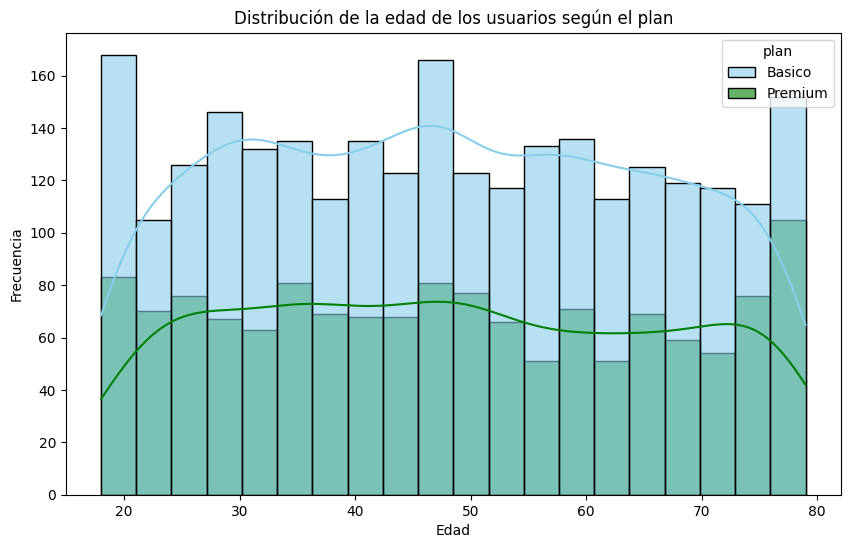

In [36]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=20,
    kde=True,
    palette=['skyblue', 'green'],
    alpha=0.6
)

plt.title('Distribución de la edad de los usuarios según el plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: La distribución de la edad se presenta uniforme a lo largo del rango observado, aproximadamente entre los 18 y 79 años. No se aprecia una concentración marcada en un grupo de edad específico ni una asimetría fuerte hacia edades jóvenes o mayores. Al comparar los planes, las distribuciones de Básico y Premium presentan una forma muy similar y se superponen en prácticamente todo el rango de edades. Esto sugiere que la edad, por sí sola, no parece diferenciar de manera clara a los usuarios de ambos planes.

El plan Básico presenta una mayor frecuencia absoluta de usuarios en casi todos los grupos de edad, lo cual probablemente se relaciona con que contiene una mayor cantidad total de clientes. Sin embargo, la forma general de ambas distribuciones es comparable.

En términos generales, no se observa un patrón evidente en el que los usuarios más jóvenes o de mayor edad prefieran claramente alguno de los dos planes. La distribución puede considerarse relativamente uniforme y sin un sesgo pronunciado.

- Distribución: Normal

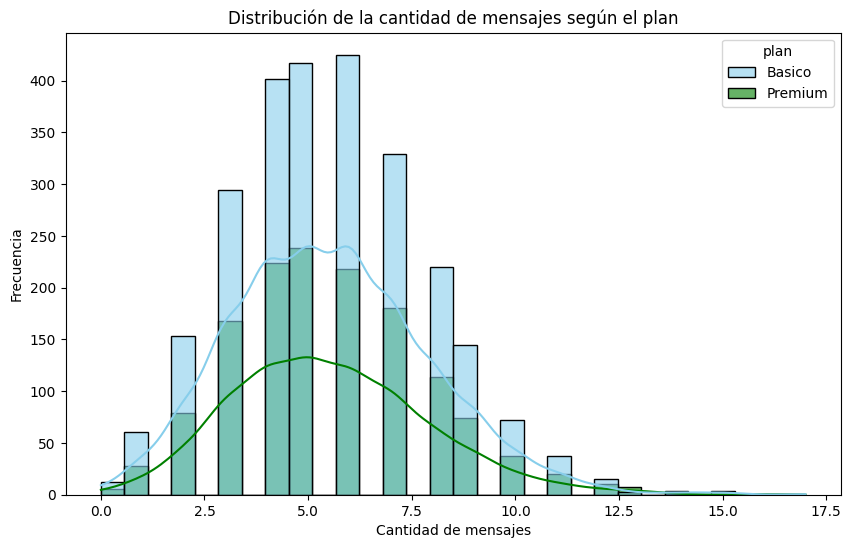

In [37]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=30,
    kde=True,
    palette=['skyblue', 'green'],
    alpha=0.6
)

plt.title('Distribución de la cantidad de mensajes según el plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: La cantidad de mensajes presenta una distribución sesgada hacia la derecha, ya que la mayoría de los usuarios se concentra aproximadamente entre 3 y 8 mensajes, mientras que existe una cola de casos con valores superiores que llega hasta alrededor de 17 mensajes.

Tanto el plan Básico como el Premium muestran una forma de distribución muy similar, con la mayor concentración alrededor de 5 a 6 mensajes. Las curvas se superponen considerablemente, por lo que no se observa una diferencia clara en el comportamiento de mensajería entre ambos planes.

El plan Básico registra frecuencias absolutas mayores en prácticamente todo el rango, lo cual puede deberse a que existen más usuarios pertenecientes a este plan y no necesariamente a que cada usuario envíe más mensajes.

También se observan pocos usuarios con cantidades de mensajes considerablemente altas, superiores a aproximadamente 12 mensajes, que podrían considerarse casos extremos o usuarios con un nivel de uso más intensivo. En general, el tipo de plan no parece generar una diferencia marcada en la distribución de la cantidad de mensajes.

- Distrubución: Rigth-skewed

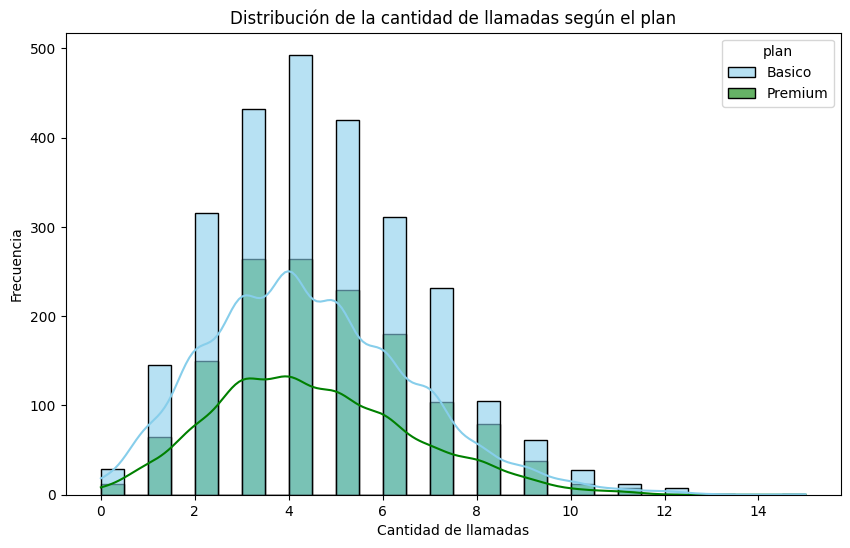

In [38]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=30,
    kde=True,
    palette=['skyblue', 'green'],
    alpha=0.6
)

plt.title('Distribución de la cantidad de llamadas según el plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: La cantidad de llamadas presenta una distribución sesgada hacia la derecha, ya que la mayor parte de los usuarios se concentra aproximadamente entre 2 y 7 llamadas, mientras que existe una cola de usuarios con cantidades mayores que llega hasta alrededor de 15 llamadas.

Tanto el plan Básico como el Premium muestran un patrón muy parecido, con la mayor concentración alrededor de 4 a 5 llamadas. Las distribuciones se superponen ampliamente, por lo que no se observa una diferencia marcada en el comportamiento de llamadas entre ambos planes.

El plan Básico presenta una frecuencia absoluta mayor en casi todos los intervalos, lo que probablemente está relacionado con que cuenta con más usuarios dentro de la muestra y no necesariamente con un mayor uso individual.

También se observan pocos usuarios con más de 10 llamadas, los cuales podrían considerarse usuarios de uso intensivo o posibles valores extremos. En general, el tipo de plan no parece diferenciar de forma clara la cantidad de llamadas realizadas por usuario.

- Distribución: Rigth-skewed

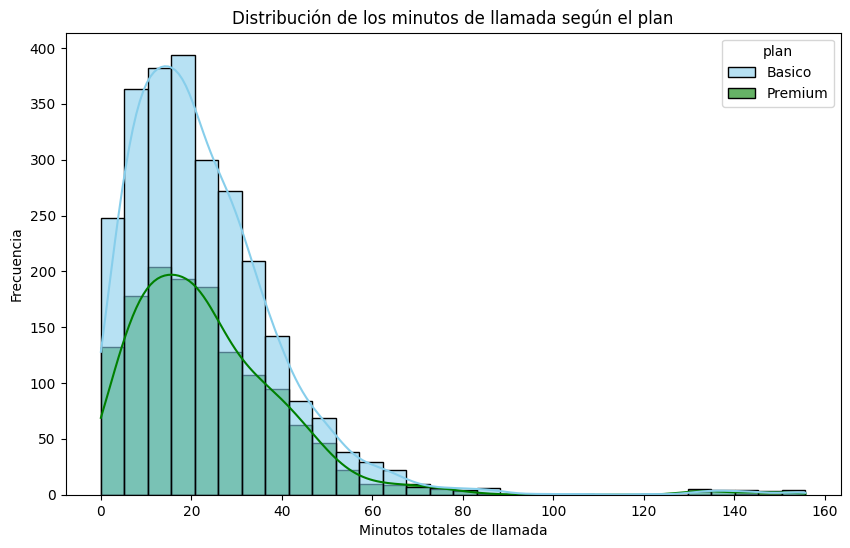

In [39]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=30,
    kde=True,
    palette=['skyblue', 'green'],
    alpha=0.6
)

plt.title('Distribución de los minutos de llamada según el plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: La distribución de los minutos totales de llamada presenta un sesgo positivo marcado hacia la derecha. La mayoría de los usuarios se concentra aproximadamente entre 0 y 40 minutos, mientras que una proporción mucho menor acumula tiempos considerablemente más altos.

Tanto los usuarios del plan Básico como los del plan Premium muestran una forma de distribución muy similar, con una mayor concentración alrededor de 10 a 25 minutos. Las curvas se superponen ampliamente, por lo que no se aprecia una diferencia clara en el patrón general de consumo de minutos entre ambos planes.

El plan Básico presenta frecuencias absolutas mayores en casi todo el rango, lo que probablemente está relacionado con una mayor cantidad total de usuarios en este plan, y no necesariamente con un mayor consumo individual.

También se observan algunos casos aislados con valores muy elevados, especialmente alrededor de 130 a 155 minutos, muy alejados del comportamiento de la mayoría. Estos registros pueden considerarse posibles outliers y conviene analizarlos en la siguiente etapa para determinar si corresponden a usuarios de uso intensivo o a valores atípicos que requieran revisión.

En general, la variable cant_minutos_llamada muestra una distribución claramente asimétrica hacia la derecha, y el tipo de plan no parece producir una separación marcada en el comportamiento de uso de minutos.

- Distribución: Rigth-skewed

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

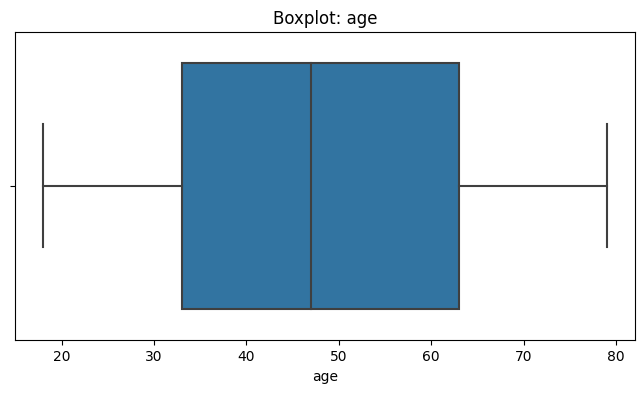

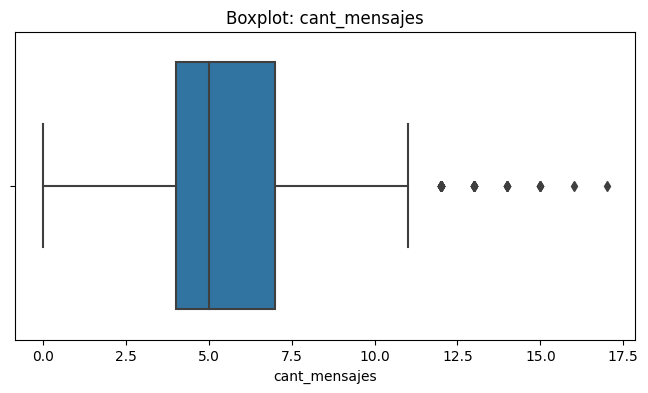

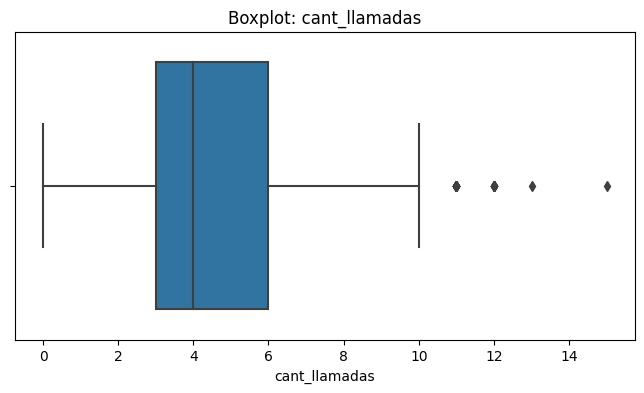

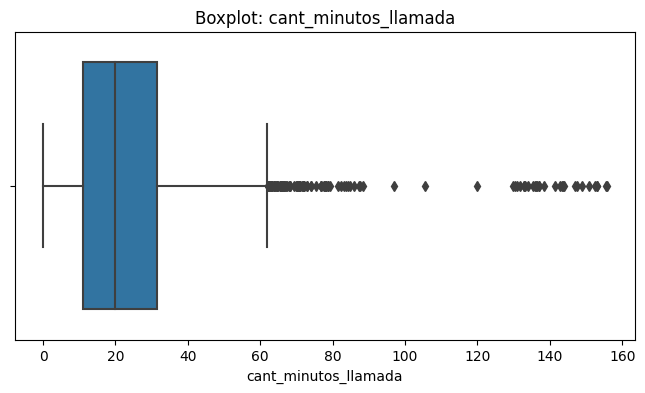

In [40]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=user_profile,
        x=col
    )
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

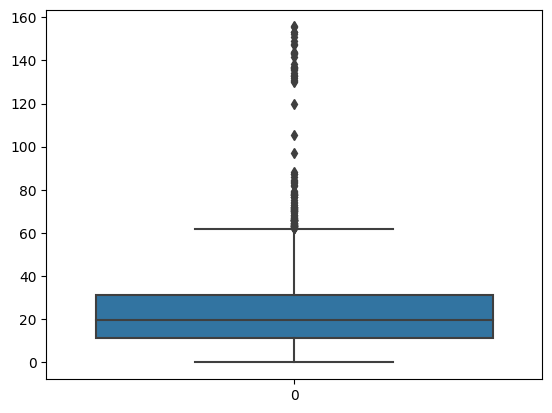

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    

    columnas_limites.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior

    })
sns.boxplot(data=user_profile[col])
plt.show()

In [47]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
resumen_outliers = []

for col in columnas_numericas:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]
    
    resumen_outliers.append({
        'variable': col,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_outliers': len(outliers)
    })

resumen_outliers = pd.DataFrame(resumen_outliers)

resumen_outliers.round(2)

,variable,limite_inferior,limite_superior,cantidad_outliers
0,age,-12.00,108.00,0
1,cant_mensajes,-0.50,11.50,46
2,cant_llamadas,-1.50,10.50,30
3,cant_minutos_llamada,-19.32,61.86,109


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se identificaron 46 outliers por encima del límite superior de 11.5 mensajes. Recomiendo mantenerlos ya que representan usuarios con una actividad de mensajería superior a la habitual y no necesariamente errores en los datos. Al tratarse de una variable de comportamiento, es razonable que existan usuarios con un uso más intensivo.
- cant_llamadas: mantener o no outliers, porqué? Se detectaron 30 outliers por encima del límite superior de 10.5 llamadas. Recomiendo conservarlos, porque estos valores pueden corresponder a usuarios que realizan llamadas con mayor frecuencia. No hay evidencia de que sean registros imposibles o incorrectos, por lo que eliminarlos podría hacer que se pierda información relevante sobre usuarios de alto uso.
- cant_minutos_llamada: mantener o no outliers, porqué? Se encontraron 109 outliers por encima del límite superior de 61.86 minutos. Aunque es la variable con mayor cantidad de valores atípicos, recomiendo mantenerlos, ya que el histograma previo mostró una distribución claramente sesgada hacia la derecha y estos valores son coherentes con la existencia de usuarios con llamadas más prolongadas o mayor consumo acumulado. Mientras los valores sean plausibles y no correspondan a errores de captura, forman parte del comportamiento real de los usuarios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
# Crear columna grupo_uso
def clasificar_uso(row):
    
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    
    else:
        return 'Alto uso'


user_profile['grupo_uso'] = user_profile.apply(
    clasificar_uso,
    axis=1
)

In [49]:
# verificar cambios
display(user_profile[[
            'user_id',
            'cant_llamadas',
            'cant_mensajes',
            'grupo_uso'
        ]
    ].head(10)
)

print('\nDistribución de usuarios por grupo de uso:')
print(user_profile['grupo_uso'].value_counts())

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso
5,10005,7.0,5.0,Uso medio
6,10006,5.0,3.0,Uso medio
7,10007,5.0,3.0,Uso medio
8,10008,5.0,5.0,Uso medio
9,10009,3.0,5.0,Uso medio



Distribución de usuarios por grupo de uso:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad
def clasificar_edad(age):
    
    if age < 30:
        return 'Joven'
    
    elif age < 60:
        return 'Adulto'
    
    else:
        return 'Adulto Mayor'


user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [51]:
# verificar cambios
display(
    user_profile[
        [
            'user_id',
            'age',
            'grupo_edad'
        ]
    ].head(10)
)

print('\nCantidad de usuarios por grupo de edad:')
print(user_profile['grupo_edad'].value_counts())

,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor
5,10005,61.0,Adulto Mayor
6,10006,39.0,Adulto
7,10007,70.0,Adulto Mayor
8,10008,76.0,Adulto Mayor
9,10009,47.0,Adulto



Cantidad de usuarios por grupo de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

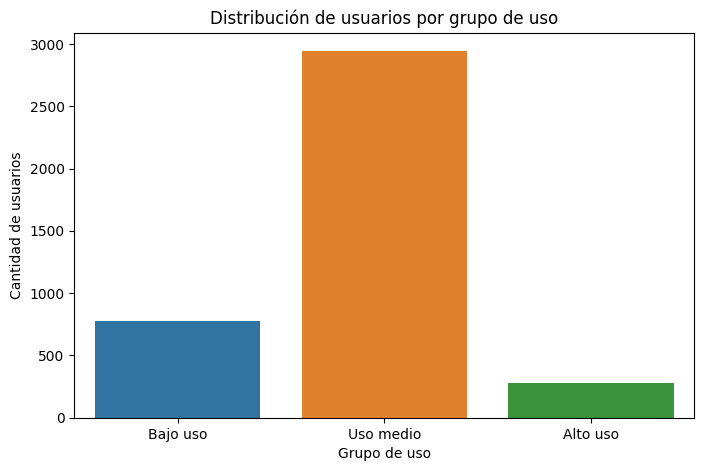

In [52]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

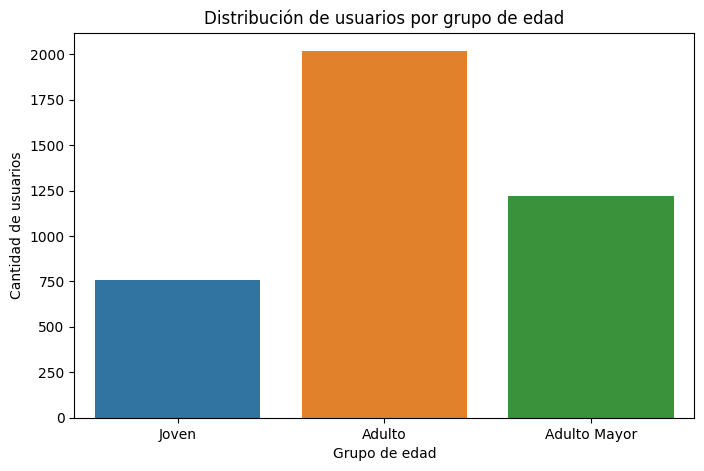

In [53]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Los principales problemas detectados fueron valores nulos, valores sentinel y fechas fuera del rango esperado.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se identificaron dos tipos de segmentación: por edad y por nivel de uso.
1. Por edad, los usuarios se clasificaron en:
- Joven (<30 años): 760 usuarios, 19.0%
- Adulto (30–59 años): 2,018 usuarios, 50.45%
- Adulto Mayor (60 años o más): 1,222 usuarios, 30.55%
El segmento predominante es el de Adultos, que representa aproximadamente la mitad de los clientes. Sin embargo, la distribución de edades entre los planes Básico y Premium es bastante similar, por lo que no se observa una relación evidente entre edad y elección del plan.
2. Por nivel de uso se identificaron:
- Bajo uso: 778 usuarios, 19.45%
- Uso medio: 2,943 usuarios, 73.58%
- Alto uso: 279 usuarios, 6.98%
El comportamiento predominante es, por tanto, el Uso medio. Cerca de tres de cada cuatro usuarios se encuentran en esta categoría, mientras que existe un grupo pequeño pero relevante de usuarios de Alto uso.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Basado en las variables de comportamiento, destacan dos segmentos con potencial crecimiento comercial.
El primero es el segmento de Uso medio, porque representa el 73.58% de la base de clientes. Su gran tamaño lo convierte en el principal grupo para estrategias de crecimiento, especialmente mediante campañas de upselling para migrar usuarios del plan Básico hacia Premium.
El segundo es el segmento de Alto uso, aunque representa solamente el 6.98% de los clientes. Estos usuarios realizan una cantidad elevada de llamadas o mensajes y pueden requerir planes con mayores beneficios, límites superiores o servicios adicionales. Por ello, podrían ser candidatos para ofertas premium o programas de fidelización.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Con el análisis usando el método IQR identificaron:
- cant_mensajes: 46 outliers, con un límite superior de 11.5 mensajes.
- cant_llamadas: 30 outliers, con un límite superior de 10.5 llamadas.
- cant_minutos_llamada: 109 outliers, con un límite superior de 61.86 minutos.
- age: 0 outliers.
La mayor cantidad de valores extremos se encuentra en los minutos de llamada. Su distribución está claramente sesgada hacia la derecha, con algunos usuarios que registran un consumo considerablemente superior al promedio.
Estos outliers se mantuvieron, ya que no parecen representar valores imposibles o errores de captura. Es más probable que correspondan a usuarios intensivos.
Para ConnectaTel, estos usuarios son importantes porque permiten identificar necesidades diferentes a las del cliente promedio. Pueden existir oportunidades para ofrecerles planes con más minutos, llamadas o beneficios adicionales, evitando que un usuario intensivo perciba limitaciones en su plan actual.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
La principal recomendación sería utilizar el nivel de uso como una variable más importante para diseñar la oferta comercial.
El segmento de Uso medio, que representa casi tres cuartas partes de los usuarios, debería ser el principal objetivo para estrategias de migración hacia planes superiores. Sería conveniente identificar dentro de este grupo a los usuarios que se encuentran cerca de los límites de Alto uso y ofrecerles una transición hacia Premium con beneficios adicionales.
Para el segmento de Alto uso, ConnectaTel podría evaluar la creación de un plan específico con más minutos, llamadas o mensajes incluidos, o bien beneficios adicionales para evitar que estos clientes intensivos encuentren mejores alternativas en la competencia.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Se identificaron problemas de calidad en los datos, principalmente 469 nulos en city (11.72%), 3,534 nulos en churn_date (88.35%), valores sentinel como -999 en age y "?" en city, así como 40 fechas de registro en 2026 (1%) que se encontraban fuera del periodo válido. En usage, duration presentó 22,076 nulos (55.19%) y length 17,896 (44.74%); estos faltantes están relacionados con el tipo de interacción y se conservaron al considerarse estructurales/MAR.


🔍 **Segmentos por Edad**

El 50.45% de los usuarios pertenece al grupo Adulto, el 30.55% a Adulto Mayor y el 19% a Joven. No se observa una separación clara entre los planes Básico y Premium según la edad.


📊 **Segmentos por Nivel de Uso**

El 73.58% de los clientes presenta Uso medio, el 19.45% Bajo uso y el 6.98% Alto uso. El grupo de Uso medio constituye el principal segmento comercial por volumen, mientras que los usuarios de Alto uso pueden representar una oportunidad para planes especializados o estrategias de fidelización.


➡️ Esto sugiere que la principal oportunidad para ConnectaTel está en segmentar la oferta de acuerdo con la intensidad real de uso y no únicamente por el plan actual del cliente. El segmento de Uso medio ofrece la mayor base para estrategias de migración, mientras que los usuarios de Alto uso pueden justificar una oferta especializada.


💡 **Recomendaciones**

Reforzar la diferenciación del plan Premium, desarrollar ofertas específicas para usuarios de alto consumo, utilizar el segmento de Uso medio para campañas de upselling, conservar y analizar los usuarios extremos como clientes potencialmente valiosos y mejorar las validaciones de calidad de datos. En una siguiente etapa debería incorporarse información de ingresos, tasa de cancelación y rentabilidad para determinar qué segmentos son realmente los de mayor valor económico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`